0.7632156744083447
[6203.90175]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


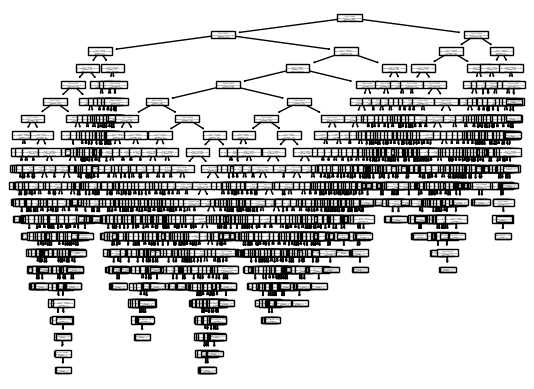

In [5]:
import pandas as pd

# Load dataset
dataset = pd.read_csv("insurance_pre.csv")

# Convert categorical to numeric
dataset = pd.get_dummies(dataset, drop_first=True)

# Input features
independent = dataset[['age', 'sex_male', 'bmi', 'children', 'smoker_yes']]

# Output target
dependent = dataset[['charges']]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0
)

# Decision Tree model
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='random'
)

regressor.fit(X_train, y_train)

# Plot tree
import matplotlib.pyplot as plt
from sklearn import tree

tree.plot_tree(regressor)
# plt.show()

# Prediction
y_pred = regressor.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score

r_score = r2_score(y_test, y_pred)
print(r_score)

import pickle

filename = "DT_Model.sav"
pickle.dump(regressor, open(filename, 'wb'))

loaded_model = pickle.load(open(filename, 'rb'))

result = loaded_model.predict([[35, 1, 30, 2, 0]])
print(result)